In [25]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
data = pd.read_csv(r'C:\Users\Pravasis Dhakal\Desktop\project code gravity\/DataEngineer.csv')
data.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,Data Engineer,$80K-$150K (Glassdoor est.),Company Description\nSagence is a management a...,4.5,Sagence\n4.5,"New York, NY","Chicago, IL",1 to 50 employees,2009,Company - Private,Consulting,Business Services,$10 to $25 million (USD),"WCI Consulting, PwC",-1
1,Senior Data Engineer (Healthcare Domain experi...,$80K-$150K (Glassdoor est.),"Key Responsibilities\n\n- Architect, build, an...",3.4,Enterprise Integration\n3.4,"New York, NY","Jacksonville, FL",51 to 200 employees,1998,Company - Private,IT Services,Information Technology,$25 to $50 million (USD),-1,-1
2,Data Engineers,$80K-$150K (Glassdoor est.),Overview\n\nJob description\n\nPosition Overvi...,5.0,Maestro Technologies\n5.0,"New York, NY","Trenton, NJ",51 to 200 employees,2003,Company - Private,IT Services,Information Technology,$5 to $10 million (USD),-1,-1
3,Client Trade Support Engineer,$80K-$150K (Glassdoor est.),About the Position\n\n\nThis position will sup...,4.8,Jane Street\n4.8,"New York, NY","New York, NY",501 to 1000 employees,2000,Company - Private,Investment Banking & Asset Management,Finance,Unknown / Non-Applicable,-1,-1
4,Data Engineer,$80K-$150K (Glassdoor est.),Data Engineer\n\nJob Details\nLevel\nExperienc...,3.7,GNY Insurance Companies\n3.7,"New York, NY","New York, NY",201 to 500 employees,1914,Company - Private,Insurance Carriers,Insurance,$100 to $500 million (USD),"Travelers, Chubb, Crum & Forster",True


In [27]:
#checking for Null Values
print(data.isnull().sum())
print(data.info())

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2528 non-null   object 
 1   Salary Estimate    2528 non-null   object 
 2   Job Description    2528 non-null   object 
 3   Rating             2528 non-null   float64
 4   Company Name       2528 non-null   object 
 5   Location           2528 non-null   object 
 6   Headquarters       2528 non-null   object 
 7   Size               2528 non-null   object 
 8   Founded            2528 non-null   int64  
 9   Ty

In [28]:
#Refactoring Coulmns and Extracting Data
data['Company Name'] = data['Company Name'].str.replace('\n.*','')
Location = data['Location'].str.split(',', expand=True,)
City = Location[0]
State = Location[1]
data['City'] = Location[0]
data['State'] = Location[1]

C:\Users\Pravasis Dhakal\AppData\Local\Temp\ipykernel_25372\3935425391.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  data['Company Name'] = data['Company Name'].str.replace('\n.*','')


In [29]:
Salary = data['Salary Estimate'].str.split('-', expand=True)
Min = Salary[0].str.replace('$', '').str.replace('K', '')
Max = Salary[1].str.replace('$', '').str.replace('K', '').str.replace('\(G.*', '')
data['Min Salary'] = Min
data['Max Salary'] = Max
data.drop('Salary Estimate', axis=1, inplace=True )

C:\Users\Pravasis Dhakal\AppData\Local\Temp\ipykernel_25372\2904328115.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  Min = Salary[0].str.replace('$', '').str.replace('K', '')
C:\Users\Pravasis Dhakal\AppData\Local\Temp\ipykernel_25372\2904328115.py:3: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  Max = Salary[1].str.replace('$', '').str.replace('K', '').str.replace('\(G.*', '')
C:\Users\Pravasis Dhakal\AppData\Local\Temp\ipykernel_25372\2904328115.py:3: FutureWarning: The default value of regex will change from True to False in a future version.
  Max = Salary[1].str.replace('$', '').str.replace('K', '').str.replace('\(G.*', '')


In [30]:
data.drop('Location', axis=1, inplace=True)
data.drop('Headquarters', axis=1, inplace=True)


In [31]:
data['Type of ownership'].value_counts()

Company - Private                 1392
Company - Public                   754
Subsidiary or Business Segment     126
-1                                 119
Nonprofit Organization              48
Unknown                             30
Government                          21
College / University                13
Contract                            10
Private Practice / Firm              6
Other Organization                   4
Hospital                             3
Self-employed                        1
School / School District             1
Name: Type of ownership, dtype: int64

In [32]:
data['Easy Apply'].value_counts()

-1      2382
True     146
Name: Easy Apply, dtype: int64

In [33]:
data['Easy Apply'].replace('-1', False, inplace=True)
data['Easy Apply'].value_counts()

False    2382
True      146
Name: Easy Apply, dtype: int64

In [34]:
# data['Job Title'].replace('Sr.', 'Senior', inplace=True)
# data['Job Title'].replace('Sr', 'Senior', inplace=True)
data['Job Title'].drop_duplicates().values

array(['Data Engineer',
       'Senior Data Engineer (Healthcare Domain experience required)',
       'Data Engineers', ..., 'F35 Software Engineer',
       'Software Engineer - AJ',
       'Future Opportunities: Software Development Engineer'],
      dtype=object)

In [35]:
data['Job Title'] = data['Job Title'].str.replace('Sr.', 'Senior')

C:\Users\Pravasis Dhakal\AppData\Local\Temp\ipykernel_25372\3985013013.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  data['Job Title'] = data['Job Title'].str.replace('Sr.', 'Senior')


In [36]:
data['Job Title'].value_counts()

Data Engineer                                          469
Senior Data Engineer                                   138
Software Engineer                                       93
Big Data Engineer                                       73
Machine Learning Engineer                               17
                                                      ... 
Senior Data Engineer (AWS)                               1
Data Center Hardware Engineer I                          1
Tier II TAC Engineer                                     1
IT Support Engineer I                                    1
Future Opportunities: Software Development Engineer      1
Name: Job Title, Length: 1252, dtype: int64

In [37]:
job_count = data['Job Title'].value_counts().rename_axis('Job Title').reset_index(name='Counts')
job_count

,Job Title,Counts
0,Data Engineer,469
1,Senior Data Engineer,138
2,Software Engineer,93
3,Big Data Engineer,73
4,Machine Learning Engineer,17
...,...,...
1247,Senior Data Engineer (AWS),1
1248,Data Center Hardware Engineer I,1
1249,Tier II TAC Engineer,1
1250,IT Support Engineer I,1


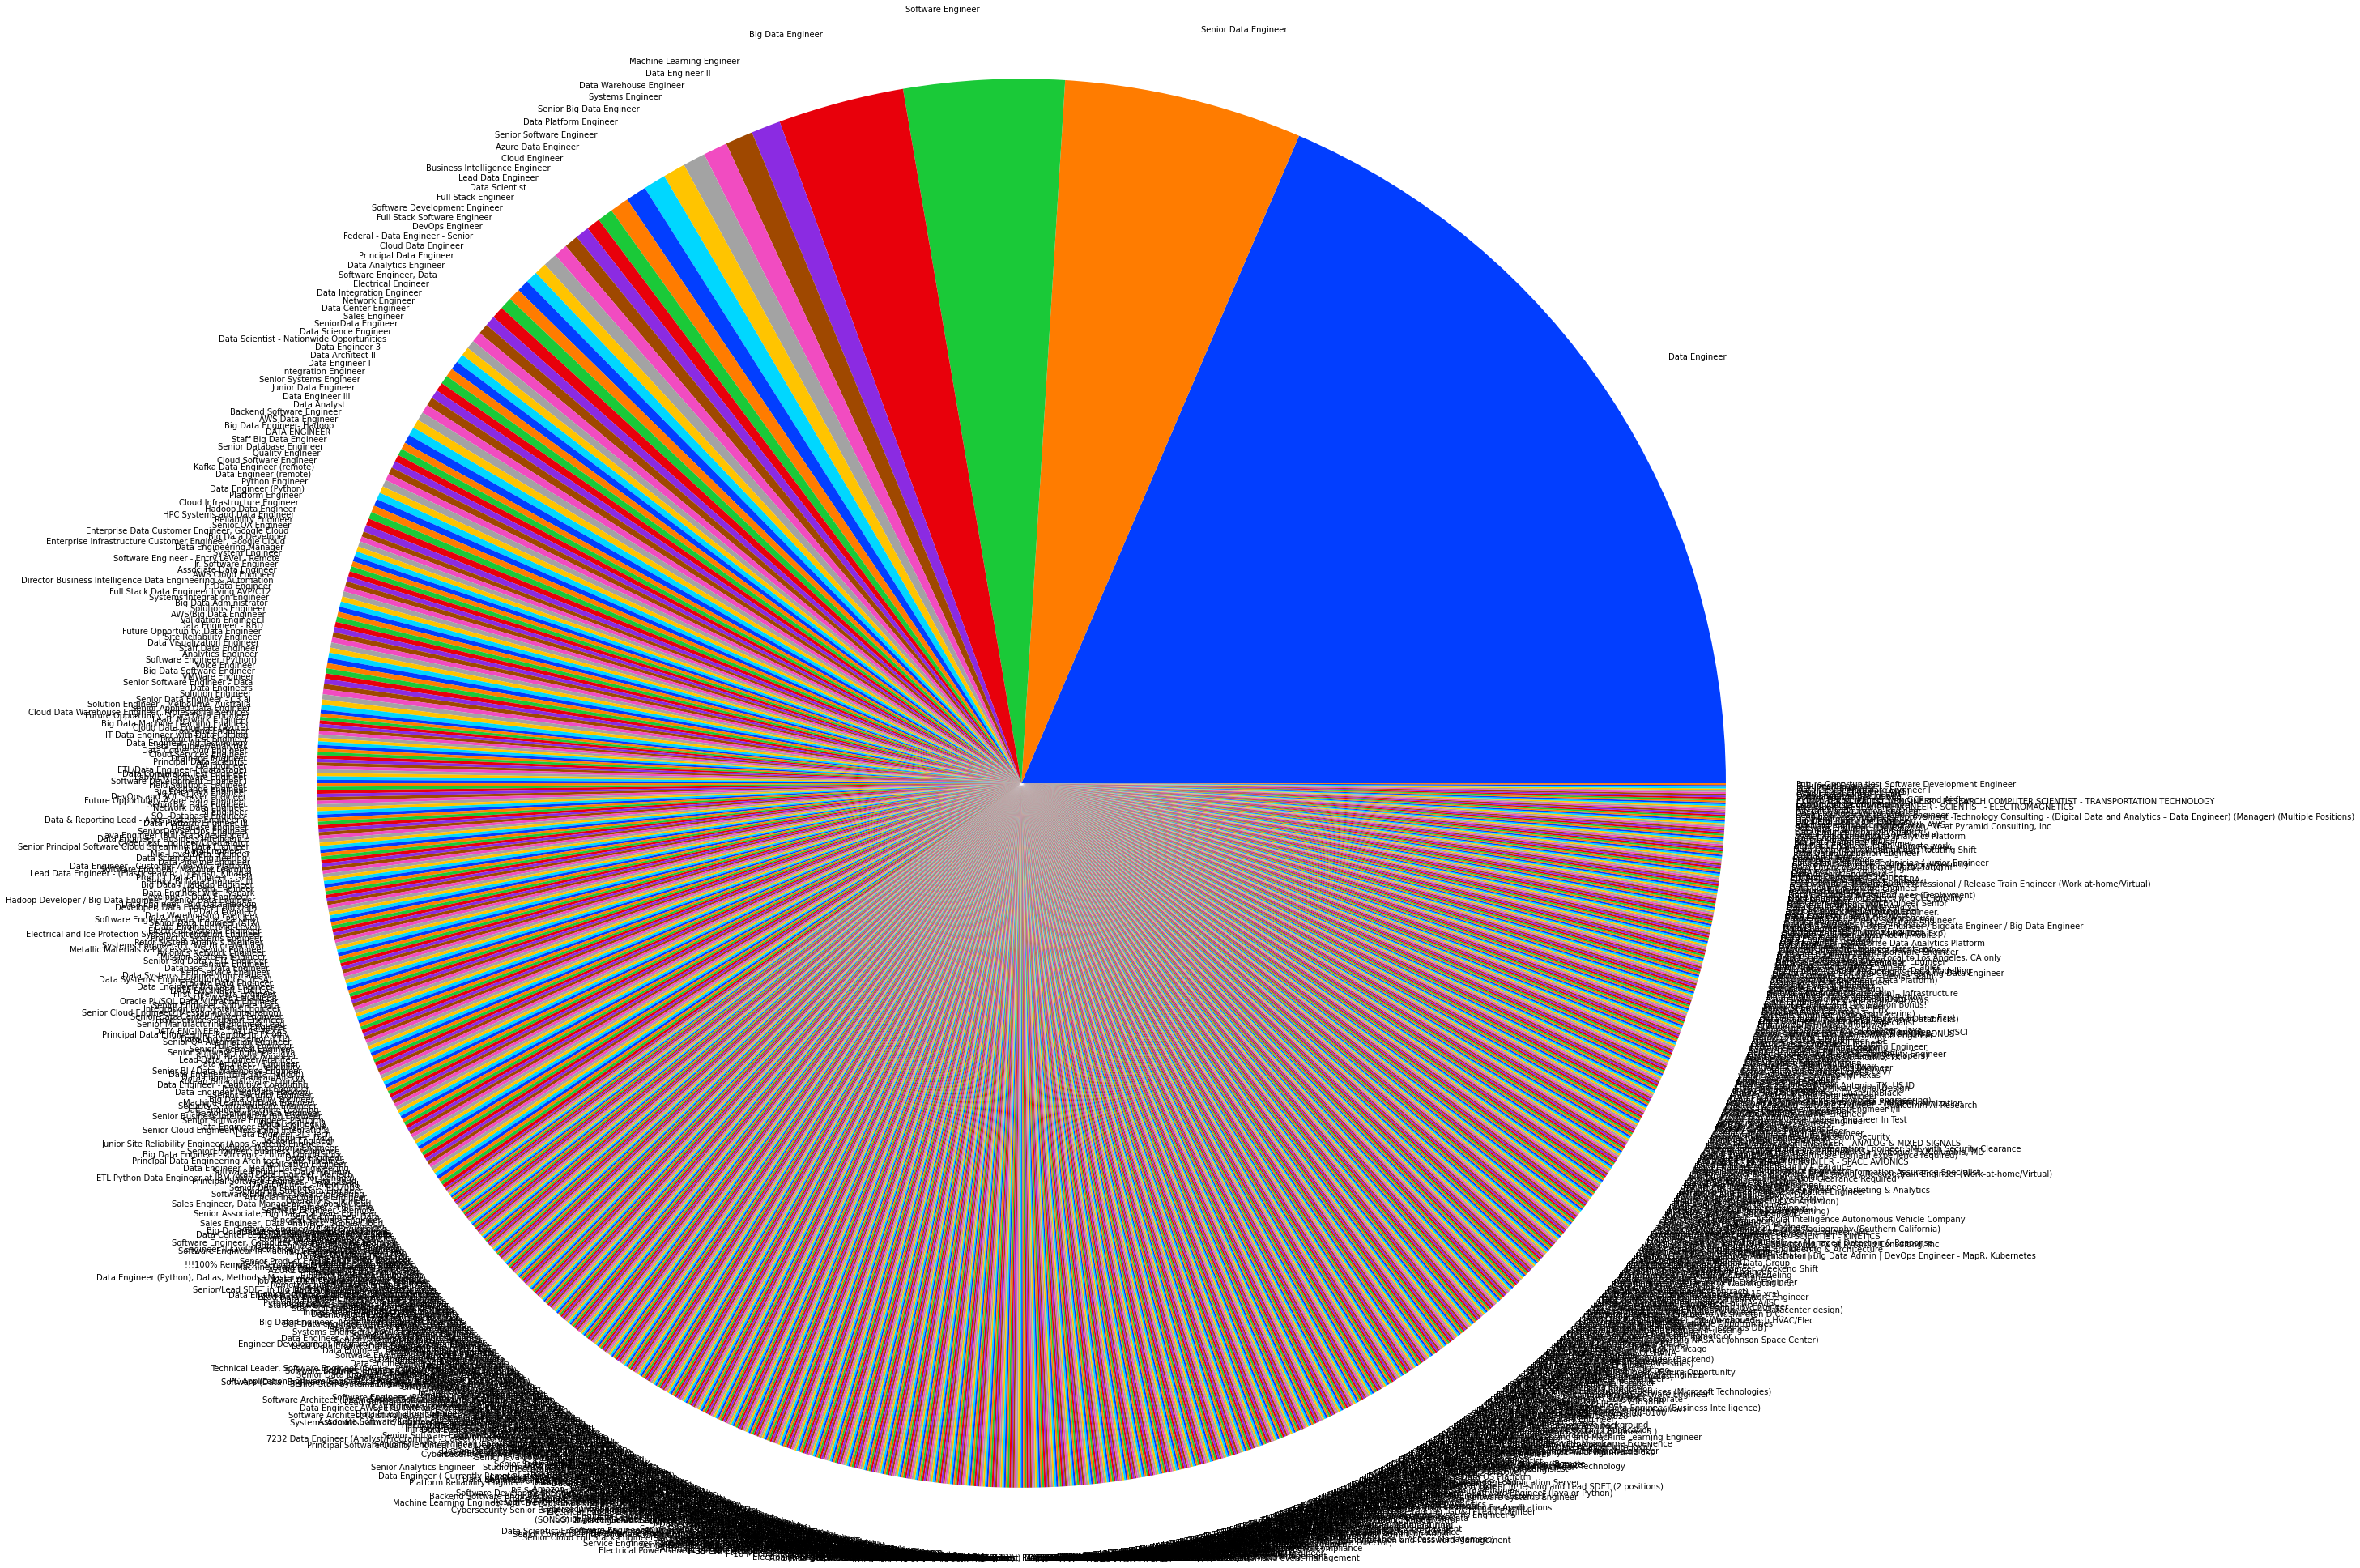

In [ ]:
plt.figure(figsize=(20,8))
# sns.lineplot(data=job_count, x='Job Title', y='Counts')
plt.pie(job_count['Counts'], labels=job_count['Job Title'], colors=sns.color_palette('bright'), radius=5)
# sns.heatmap(data=tmp.corr(), annot=True, linewidths=.5, cmap='Greens')
plt.show()

In [1]:
job_count_top10 = job_count.head(10)

plt.figure(figsize=(15, 6))  # Adjust figure size

# Scatter plot with Job Title on X-axis and Counts on Y-axis
plt.scatter(job_count_top10['Job Title'], job_count_top10['Counts'], 
            color=sns.color_palette('bright')[0],  # Use a single bright color
            s=100)  # Adjust dot size

plt.xlabel("Job Title")
plt.ylabel("Counts")
plt.title("Top 10 Job Titles vs. Counts")
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)  # Add grid lines

plt.show()

NameError: name 'job_count' is not defined

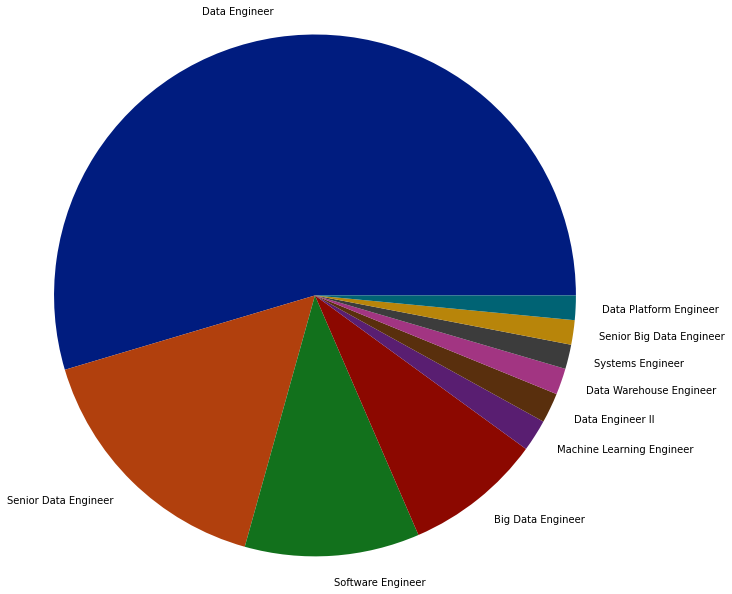

In [39]:
plt.pie(job_count['Counts'].head(10), labels=job_count['Job Title'].head(10), colors=sns.color_palette('dark'), radius=3)
# sns.heatmap(data=tmp.corr(), annot=True, linewidths=.5, cmap='Greens')
plt.show()

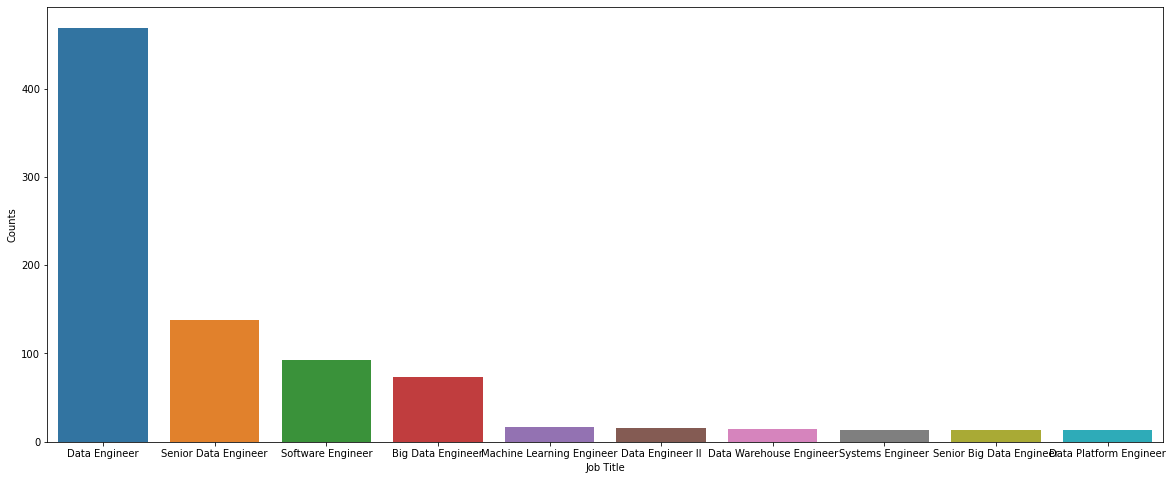

In [40]:
plt.figure(figsize=(20,8))
sns.barplot(x='Job Title', y='Counts', data=job_count.head(10))
plt.show()

In [41]:
# plt.figure(figsize=(20,8))
# sns.barplot(x='Job Title', y='Salary', data=job_count['Job Title', 'Counts'].head(10))
# plt.show()
data['Max Salary'] = data['Max Salary'].str.strip()
data['Max Salary'] = data['Max Salary'].str.lstrip()

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2528 non-null   object 
 1   Job Description    2528 non-null   object 
 2   Rating             2528 non-null   float64
 3   Company Name       2528 non-null   object 
 4   Size               2528 non-null   object 
 5   Founded            2528 non-null   int64  
 6   Type of ownership  2528 non-null   object 
 7   Industry           2528 non-null   object 
 8   Sector             2528 non-null   object 
 9   Revenue            2528 non-null   object 
 10  Competitors        2528 non-null   object 
 11  Easy Apply         2528 non-null   object 
 12  City               2528 non-null   object 
 13  State              2528 non-null   object 
 14  Min Salary         2528 non-null   object 
 15  Max Salary         2528 non-null   object 
dtypes: float64(1), int64(1),

In [43]:
data['Max Salary'].drop_duplicates().values

array(['150', '94', '154', '113', '75', '121', '117', '136', '167', '146',
       '106', '201', '164', '98', '108', '158', '210', '99', '72', '100',
       '107', '84', '92', '103', '123', '122', '104', '141', '126', '145',
       '187', '138', '97', '101', '166', '105', '130(Employer est.)',
       '281', '93', '135', '80', '53', '63', '181', '198', '132', '217',
       '151', '127', '124', '110', '109', '134', '188', '192', '199',
       '163', '96', '177', '85', '50', '77', '76', '120', '60', '160',
       '74', '89', '128'], dtype=object)

In [44]:
data['Max Salary'] = data['Max Salary'].str.replace('\(Employer est.\)', '')
# data['Max Salary'] = data['Max Salary'].str.replace('(', '')
# data['Max Salary'] = data['Max Salary'].str.replace(')', '')

C:\Users\Pravasis Dhakal\AppData\Local\Temp\ipykernel_25372\2307782351.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  data['Max Salary'] = data['Max Salary'].str.replace('\(Employer est.\)', '')


In [45]:
data['Max Salary'].drop_duplicates().values

array(['150', '94', '154', '113', '75', '121', '117', '136', '167', '146',
       '106', '201', '164', '98', '108', '158', '210', '99', '72', '100',
       '107', '84', '92', '103', '123', '122', '104', '141', '126', '145',
       '187', '138', '97', '101', '166', '105', '130', '281', '93', '135',
       '80', '53', '63', '181', '198', '132', '217', '151', '127', '124',
       '110', '109', '134', '188', '192', '199', '163', '96', '177', '85',
       '50', '77', '76', '120', '60', '160', '74', '89', '128'],
      dtype=object)

In [46]:
convert_dict = {'Max Salary': int}
data = data.astype(convert_dict)
# data['Max Salary'] = data['Max Salary'].astype(object).astype(int)

In [47]:
data[['Job Title', 'Max Salary']].sort_values(by=['Max Salary'], ascending=False).head(10)

,Job Title,Max Salary
1193,Data Engineer - Manager,281
1192,BI Engineer,281
1186,Director Business Intelligence Data Engineerin...,281
1187,machine learning Engineer with AWS,281
1188,Data Engineer / IOT Company,281
1189,Big Data - Software Engineer,281
1191,Lead Data Engineer,281
1190,VMWare Engineer,281
1199,"Data Engineer- Wilmington, DE",281
1198,Python Software Engineer,281


In [48]:
sorted_data = data[['Job Title', 'Max Salary']].sort_values(by=['Max Salary'], ascending=False)

In [49]:
sorted_data = sorted_data[sorted_data['Max Salary'] == sorted_data['Max Salary'].max()]
sorted_data

,Job Title,Max Salary
1193,Data Engineer - Manager,281
1192,BI Engineer,281
1186,Director Business Intelligence Data Engineerin...,281
1187,machine learning Engineer with AWS,281
1188,Data Engineer / IOT Company,281
1189,Big Data - Software Engineer,281
1191,Lead Data Engineer,281
1190,VMWare Engineer,281
1199,"Data Engineer- Wilmington, DE",281
1198,Python Software Engineer,281


In [50]:
data1 = data.groupby('Job Title')[['Min Salary', 'Max Salary']].mean()
data1.sort_values(by='Max Salary',ascending=False).head(25)

,Max Salary
Job Title,
machine learning Engineer with AWS,281.0
"Data Engineer- Wilmington, DE",281.0
Data Engineer / IOT Company,281.0
Data Engineer - Manager,281.0
Python Software Engineer,281.0
Senior SSIS Data Integration Engineer,281.0
Big Data - Software Engineer,281.0
"IT Advisor, Performance Improvement -Technology Consulting - (Digital Data and Analytics – Data Engineer) (Manager) (Multiple Positions)",281.0
"Senior Staff Engineer, CAD",217.0
